# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [1]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats

In [2]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [4]:

#cargamos los datos como arreglos numpy
#features= np.loadtxt("/content/drive/MyDrive/Astronomia y Big data/notebooks_clases/RRLyrae_features_small.txt", delimiter=',')
#targets= np.loadtxt("/content/drive/MyDrive/Astronomia y Big data/notebooks_clases/RRLyrae_labels_small.txt", delimiter=',')
features= np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("RRLyrae_labels_small.txt", delimiter=',')


In [5]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


### Preguntas
1. ¿Este es un problema de clasificación o regresión?
2. ¿Es un problema binario o multiclase?
3. ¿Qué representa la variable objetivo?
4. ¿Las clases están balanceadas o desbalanceadas?
5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?

1. Problema de clasificación, se busca determinar si las estrellas son o no son del tipo RR Lyrae
2. Es binario, las clasificaciones de las estrellas son: 1. La estrella es RR Lyrae; 0. La estrella no es RR Lyrae
3. La variable objetivo es la variable que nosotros buscamos predecir. En este caso la variable objetivo es si la estrella es RR Lyrae o no, por lo que representa la clase a la que pertenece la estrella
4. Observando el conjunto de datos, las clases están muy desbalanceadas, pues en el conjunto de datos hay casi 4 veces más estrellas que no son RR Lyrae, que las que si son
5. Saber que las clases están desbalanceadas o balanceadas es importante, pues no podemos tratar un conjunto de datos desbalanceado de la misma manera que tratariamos un conjunto de datos balanceado. La razón de esto es que si tenemos datos mal distribuidos, entrenarlo con un conjunto aleatorio podría resultar en un grave error, pues para que el algoritmo encuentre un modelo ideal necesita una buena proporción de ambas clases. Si dentro de nuestro conjunto aleatorio tenemos demasiadas estrellas que se clasificaron como NO RR Lyrae, y muy pocas clasificadas como RR Lyrae, entonces el modelo necesitaría utilizar otras métricas o realizar un análisis más profundo, aunque aún así esto podría no resultar en un buen modelo

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

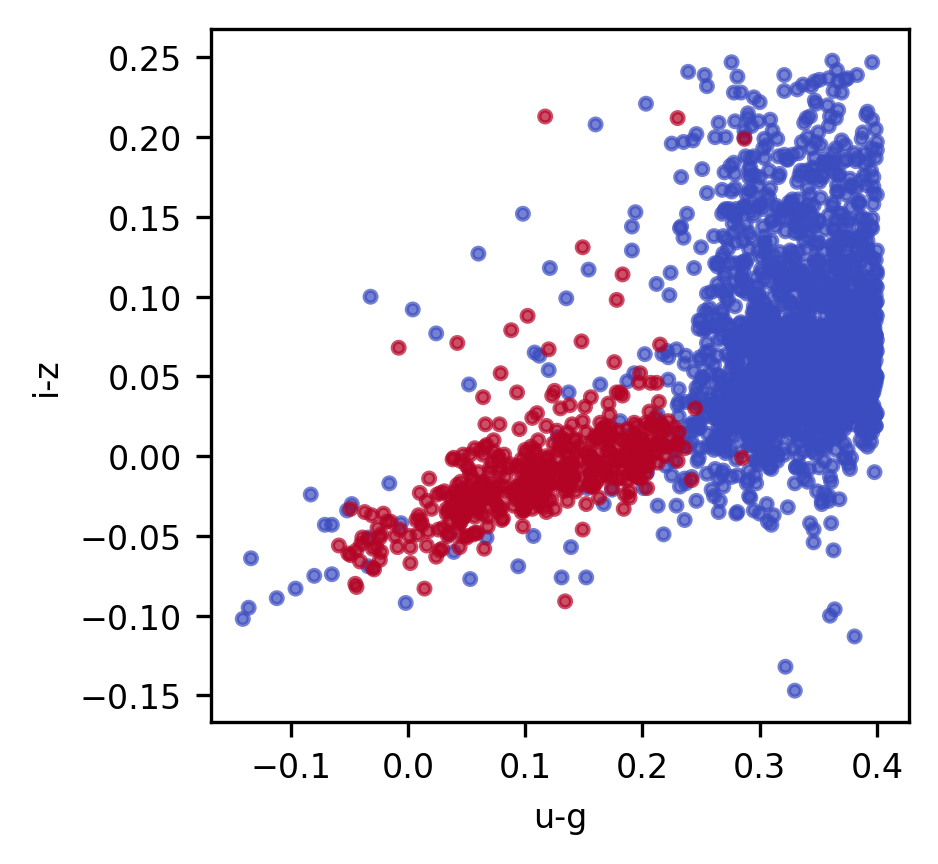

In [8]:
#complete la celda
plt.figure(figsize=(3,3))

sc=plt.scatter(df['u-g'], df['i-z'], c=df['RR_Lyrae'], cmap='coolwarm', s=8, alpha=0.7)
plt.xlabel('u-g')
plt.ylabel('i-z')
plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?
2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?

 1. En este problema, las RR Lyrae suelen concentrarse en una zona relativamente
acotada del espacio u-g / i-z (colores más "azules"), aunque hay superposición
 parcial con las estrellas normales. Como se insinúa cierta separación (no
 perfecta)
2. Es razonable esperar que un árbol de decisión logre un desempeño
razonable, aunque probablemente no perfecto, ya que tendrá que lidiar con la
 zona de superposición entre ambas clases.

#### Separe los datos en entrenamiento y prueba

In [9]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [10]:
#complete la celda
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3, random_state=42)

In [11]:
X_train.shape

(1738, 4)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?
2. ¿Por qué eso podría afectar la evaluación del modelo?
3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

1. Si hacemos una partición completamente aleatoria podría darse que la proporción de una clase (probablemente la que no es RR Lyrae) sea mucho mayor que la otra. En ese caso, durante el entrenamiento el modelo podría no tener la suficiente información para llegar a una conclusión factible.
2. Si el modelo no está bien entrenado no tiene como saber que características debe cumplir una RR Lyrae
3. Con respecto a construir los conjuntos de entrenamiento y prueba, lo más razonable sería no realizar una separación aleatoria, si no que determinar manualmente la cantidad de datos de cada clase que queremos para entrenamiento y para prueba, de modo que tengamos una proporción razonable.

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [12]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)
#entrene el modelo y genere las predicciones
y_pred=model_tree.predict(X_test)


In [13]:
df.RR_Lyrae.value_counts()

RR_Lyrae
0    2000
1     483
Name: count, dtype: int64

#### Visualicemos el árbol

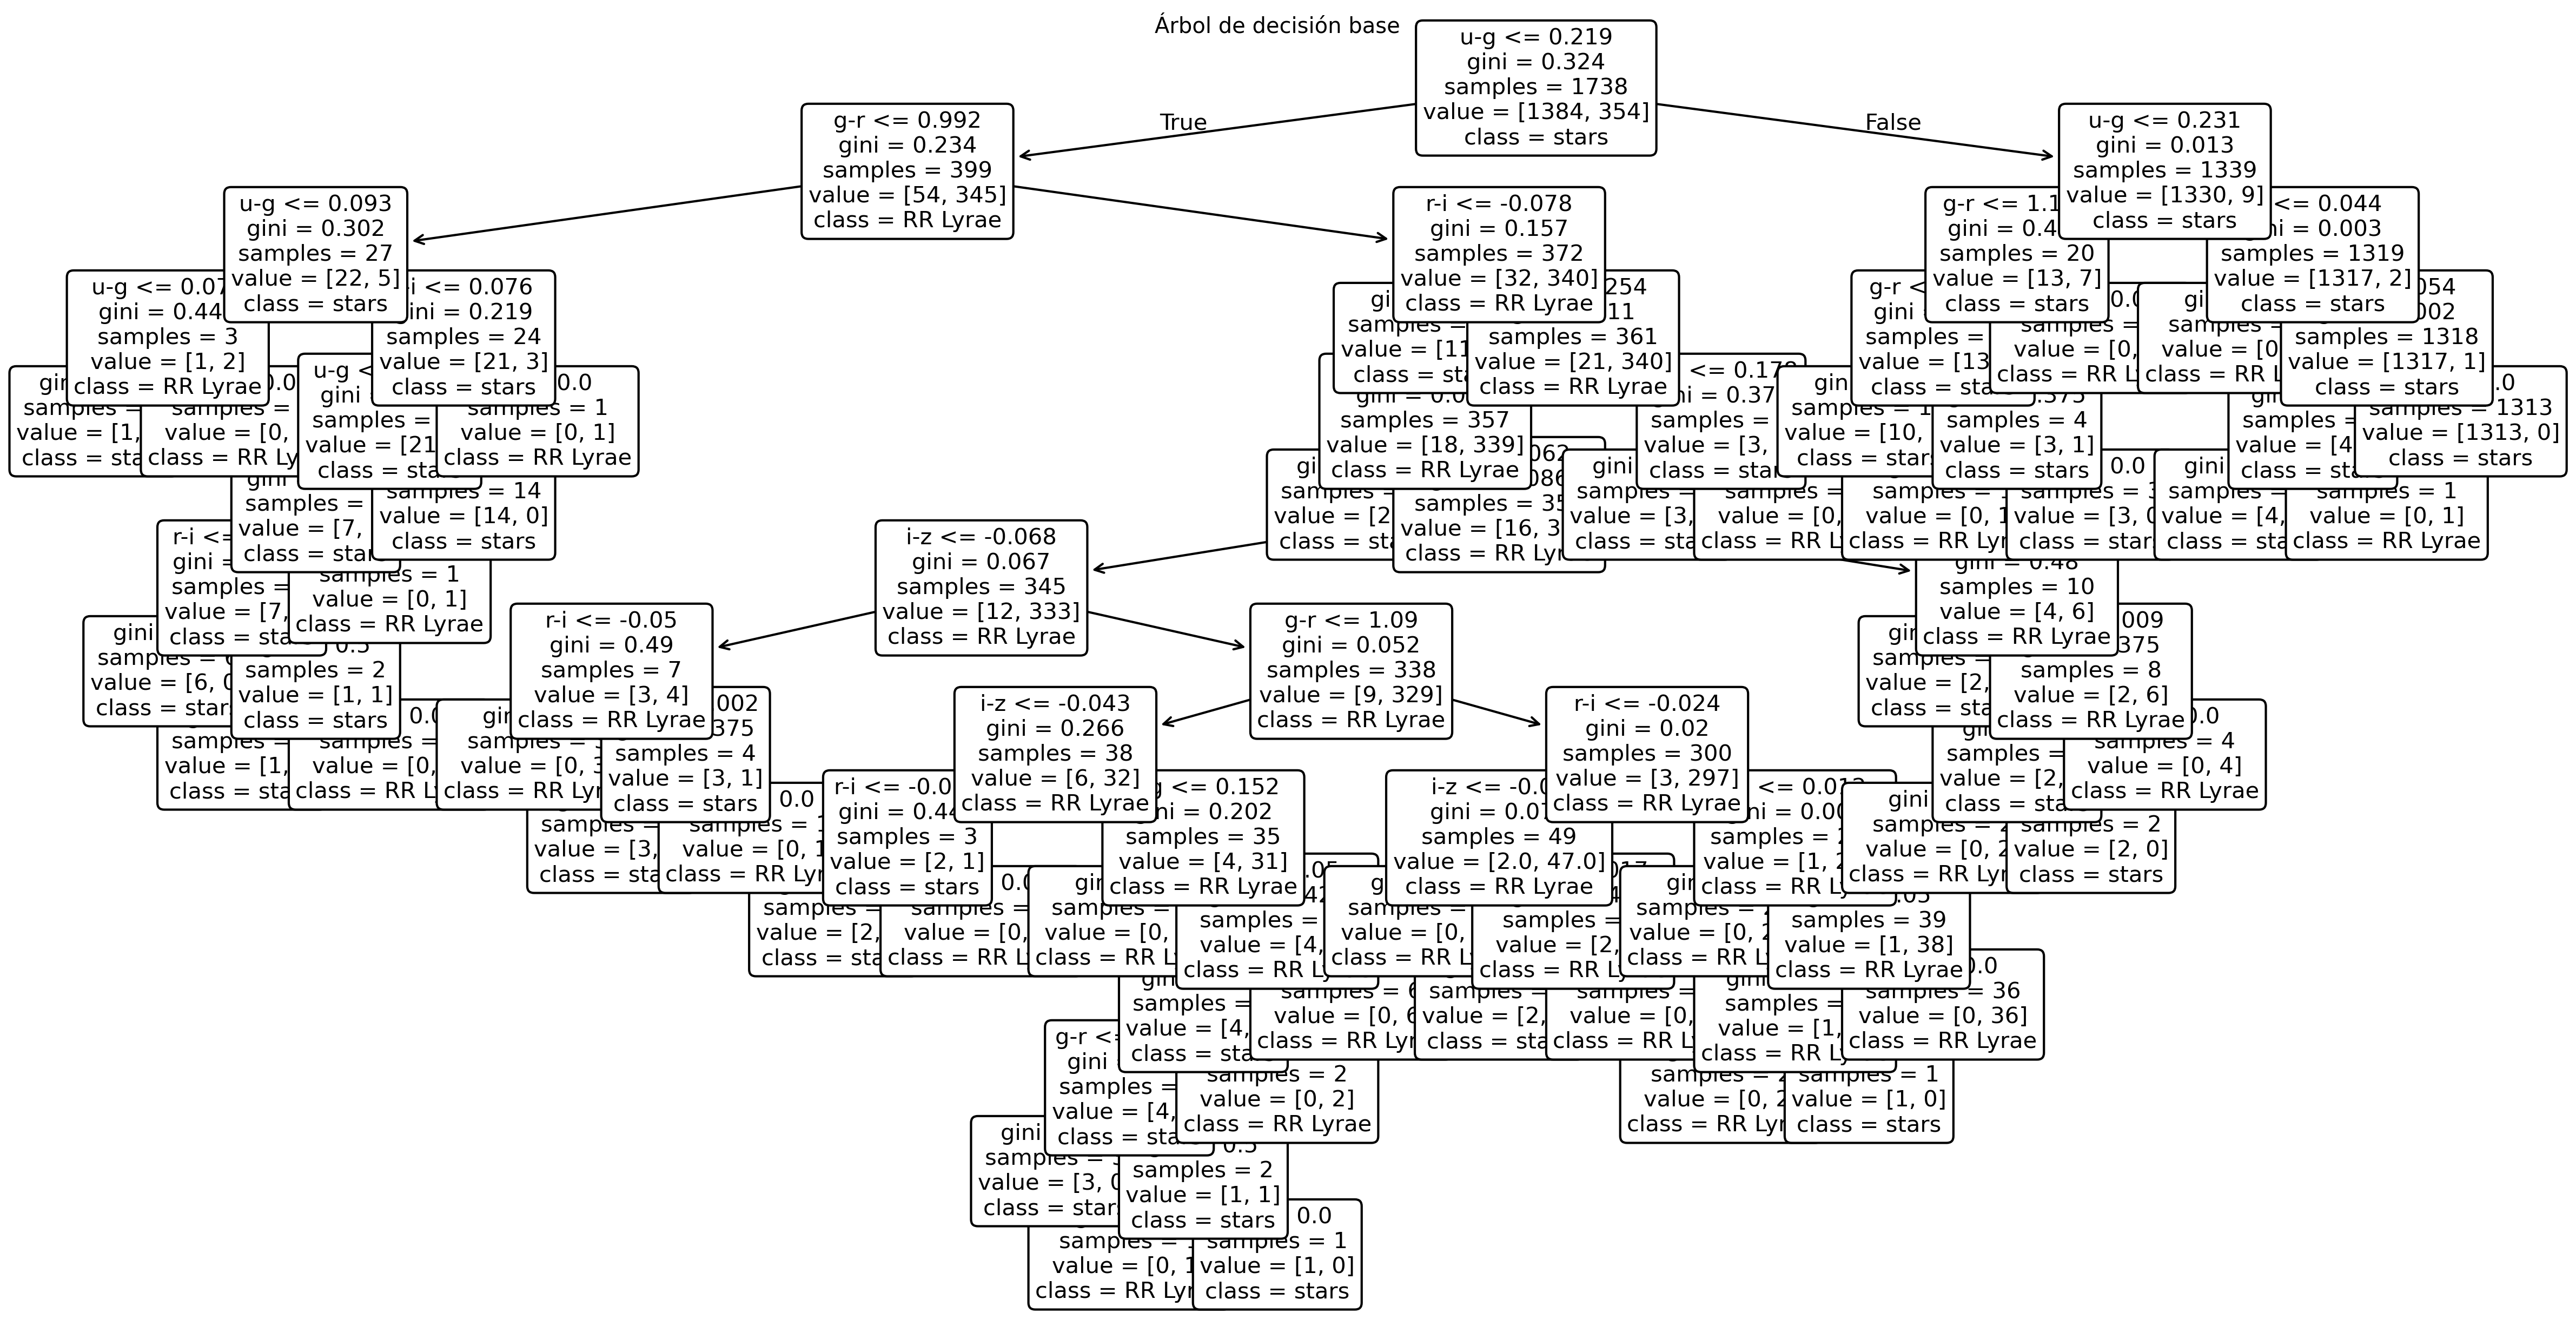

In [14]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

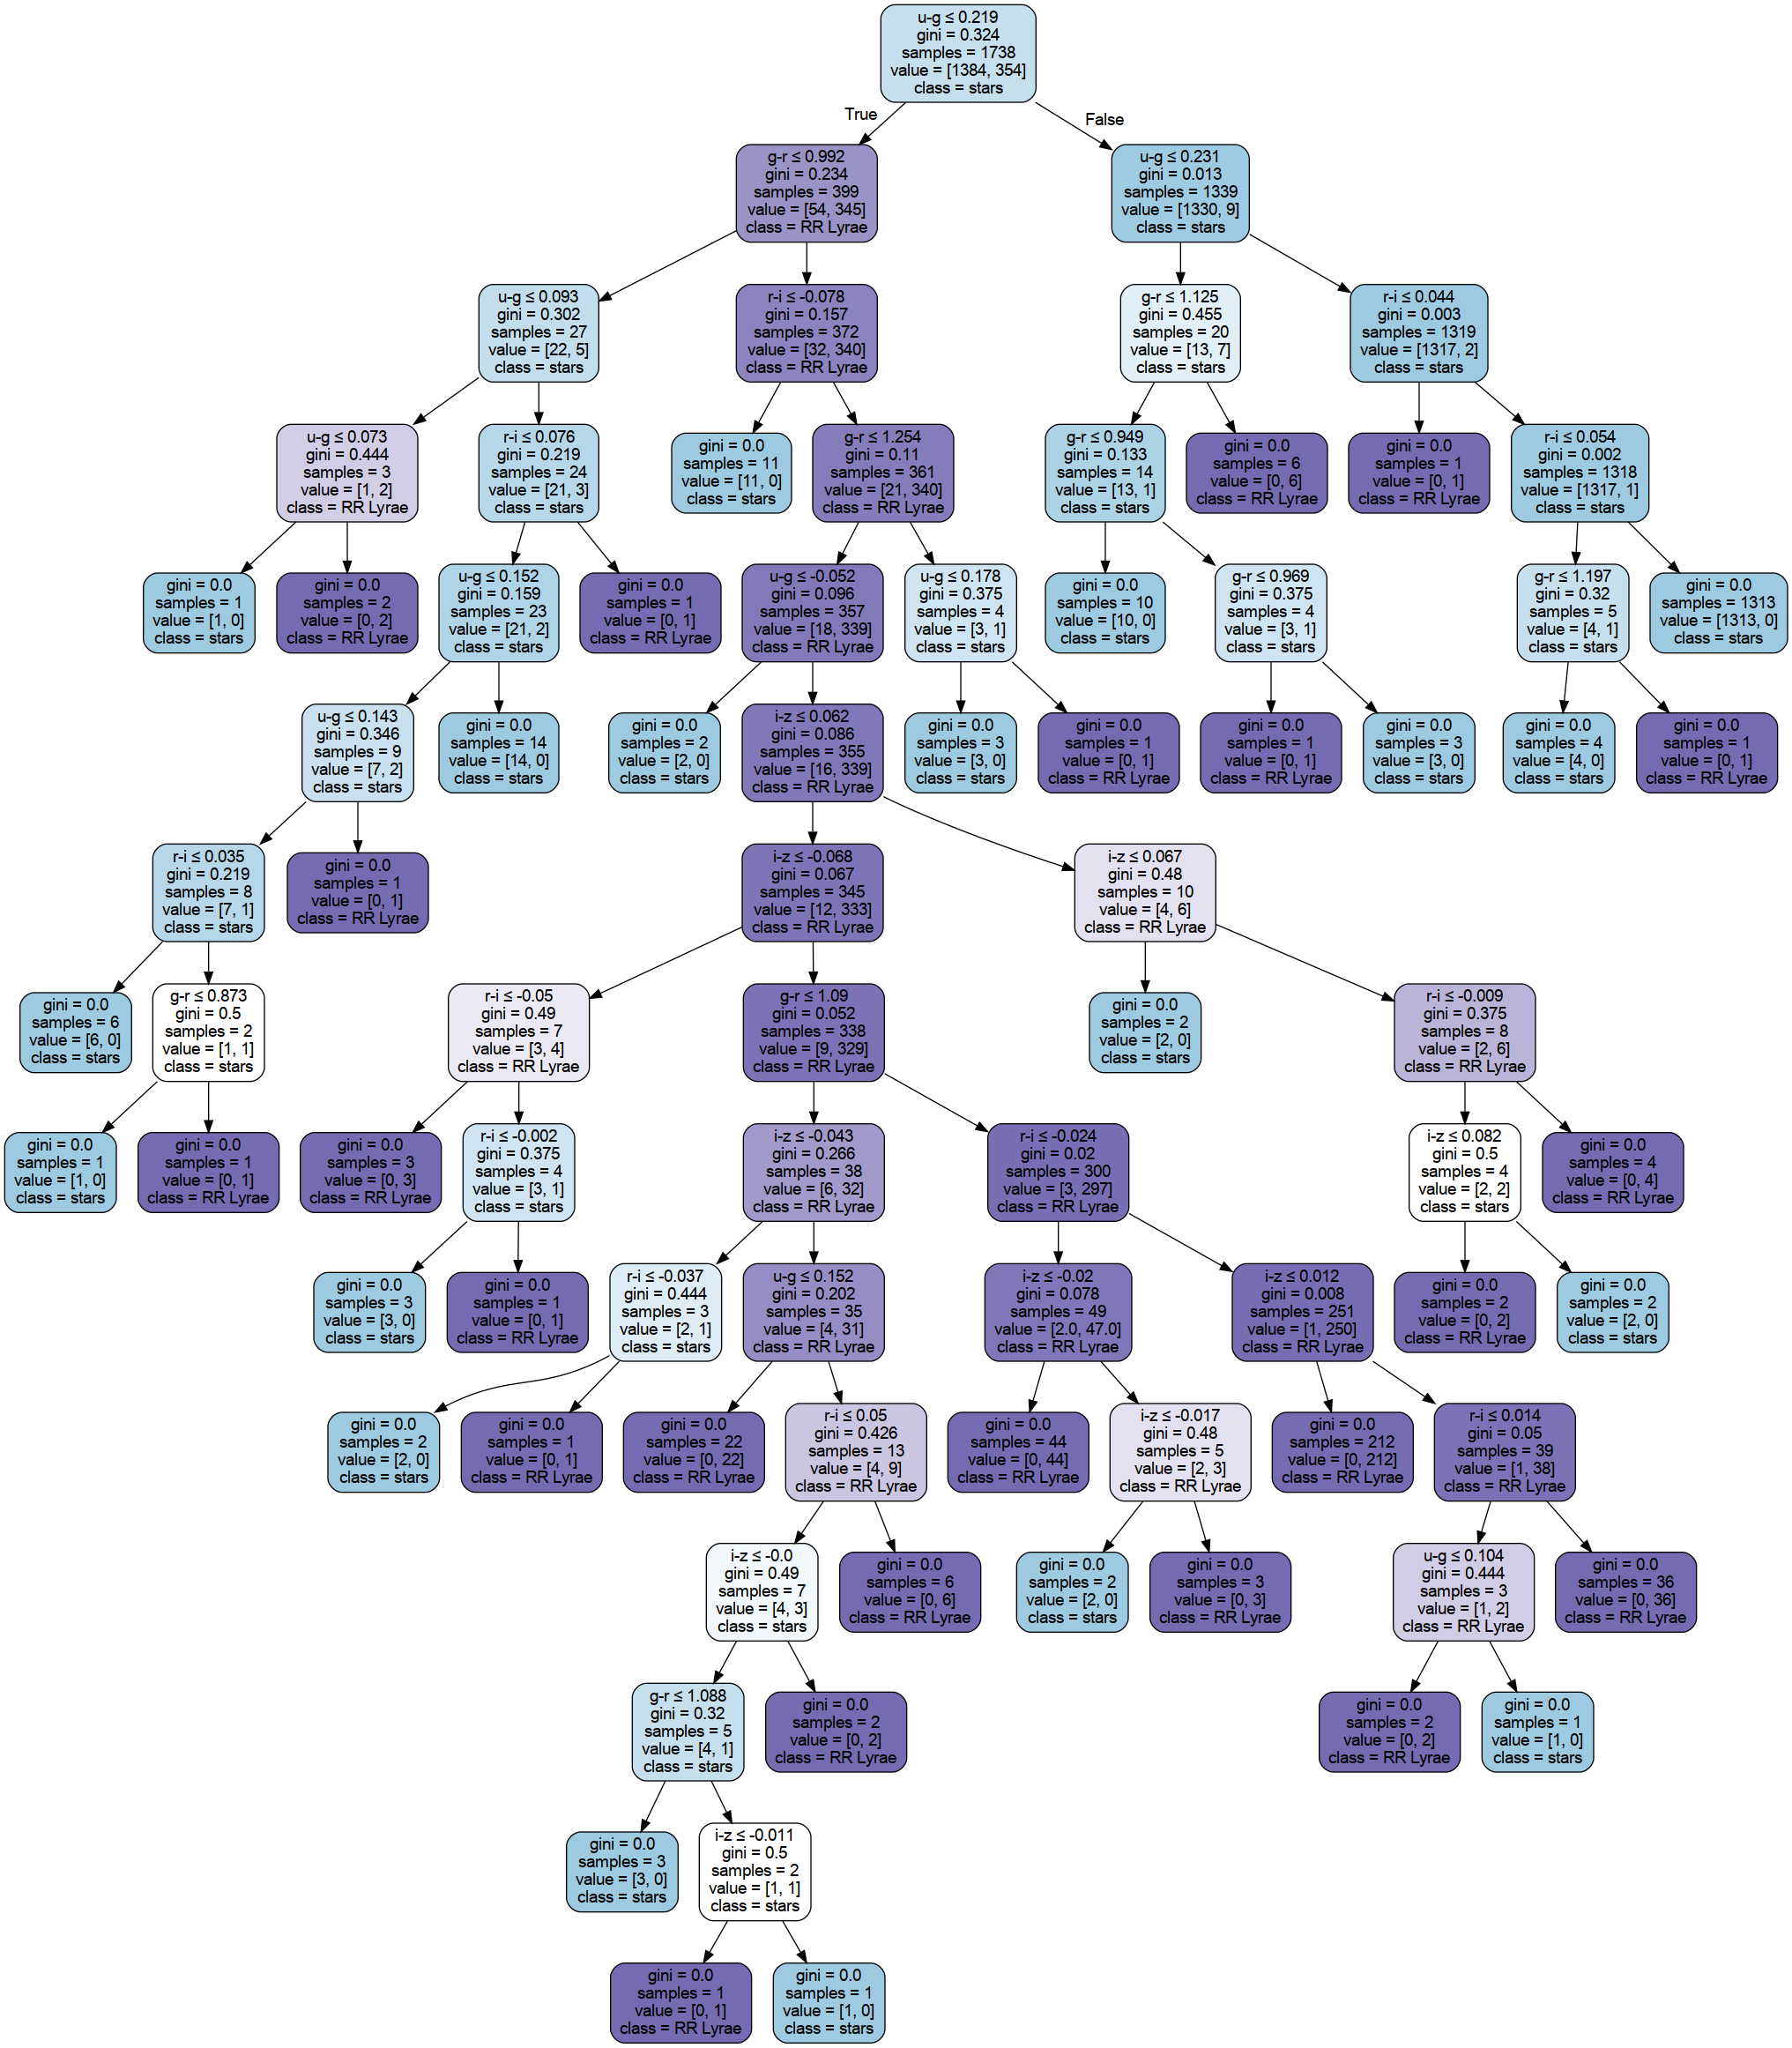

In [15]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.
2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

1. El árbol es demasiado complejo, pues sin hiperparámetros este tiende a sobreajustar. Con tantas features, ajustar todo hasta un GINI=0 se vuelve una tarea de ultra precisión, lo que no necesariamente es algo bueno. En total, se presentan 14 niveles, lo que significa que el algoritmo tuvo que realizar demasiados cortes en el conjunto de datos para poder llegar a la solución que le de un score train = 100%
2. La desventaja de un árbol demasiado grande para este problema, es que puede significar que hubo un sobreajuste. El algoritmo no se preocupó de dar una solución óptima, sino que simplemente buscó llegar al 100% de score train y dar esa solución. Un modelo demasiado complejo como este suele describirse como una varianza alta, lo que significa que el algoritmo fue demasiado sensible al conjunto de entrenamiento, y probablemente no tenga muy buen rendimiento con el conjunto de prueba

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [16]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.9651006711409396


#### Otras métricas

In [17]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.8759124087591241
Recall   : 0.9302325581395349
F1-score : 0.9022556390977443


In [18]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[599,  17],
       [  9, 120]])

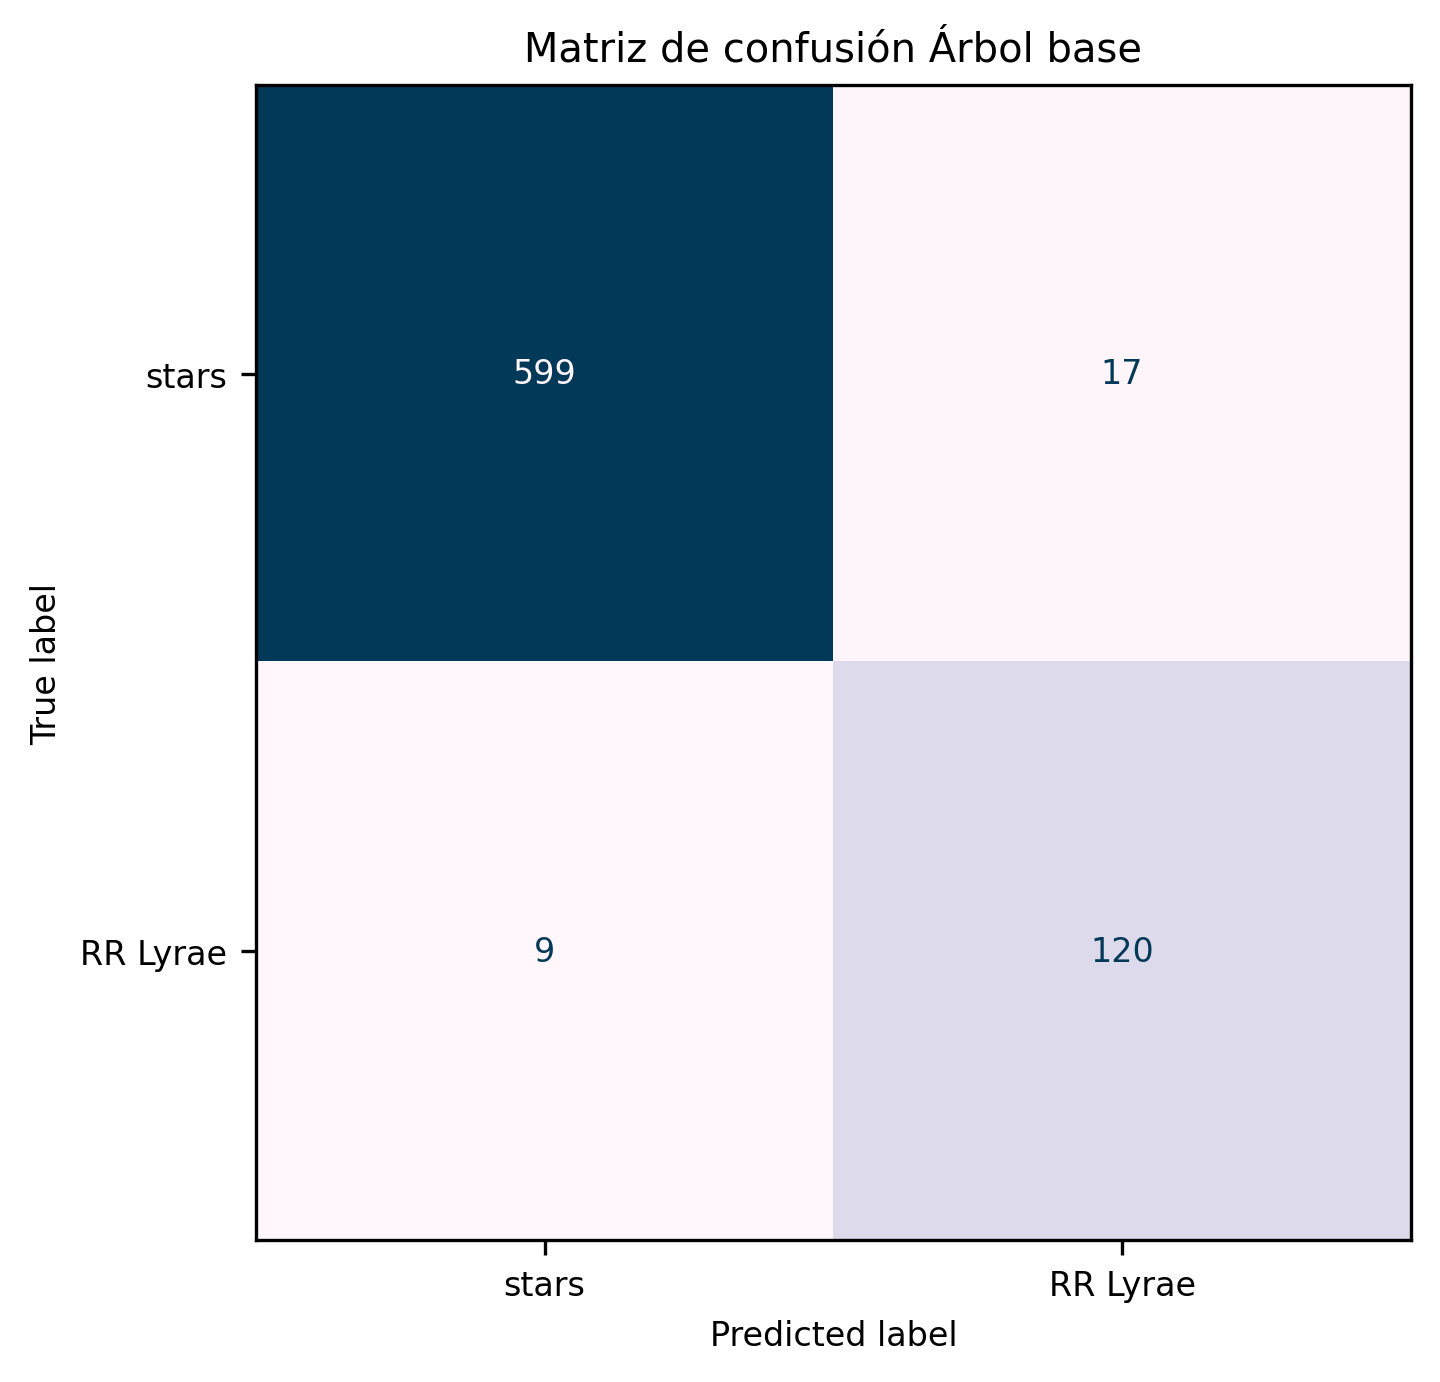

In [19]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   - verdaderos negativos (TN)
   - falsos positivos (FP)
   - falsos negativos (FN)
2. Calcule las métricas "a mano"



1. TP: 120 ; TN: 599 ; FP: 17 ; FN: 9
2. Precision = 120 / (120 + 17) = 0.876
Recall = 120 / (120 + 9) = 0.930
F1-Score = 2 * (0.876 * 0.930) / (0.876 + 0.930) = 0.902

### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo
   - un falso negativo

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?

1. FP: Durante la prueba, el modelo determinó incorrectamente que una estrella era RR Lyrae, cuando en realidad no lo era ; FN: Durante la prueba, el modelo determinó incorrectamente que una estrella no era RR Lyrae, cuando en realidad si lo era
2. Si el objetivo es encontrar la mayor cantidad de RR Lyrae, el error que más nos preocuparía sería una alta cantidad de falsos negativos, pues estamos perdiendo información sobre RR Lyrae verdaderas al detectarlas como estrellas
3. Si el objetivo es encontrar una muestra final limpia, el error que más nos preocuparía sería una alta cantidad de falsos positivos, pues el modelo estaría entregando información incorrecta al predecir RR Lyrae que en realidad no lo son.

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [20]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [21]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x730edb676130>

In [22]:
for train, test in cv1.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [23]:
for train, test in cv2.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [24]:
for train, test in cv3.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [25]:
scores1 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv3, scoring = 'accuracy')

In [26]:
scores3

{'fit_time': array([0.0072875 , 0.00613689, 0.00737119, 0.00722337, 0.00654125]),
 'score_time': array([0.00219059, 0.00213718, 0.00207019, 0.00207973, 0.00217724]),
 'test_score': array([0.97987928, 0.96780684, 0.96579477, 0.97782258, 0.95967742])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [27]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.785 0.380


In [28]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.967 0.010


In [29]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.970 0.008


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [30]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/home/huawei/miniconda3/envs/ciencia/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/huawei/miniconda3/envs/ciencia/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/huawei/miniconda3/envs/ciencia/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/h

In [31]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [32]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/home/huawei/miniconda3/envs/ciencia/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/huawei/miniconda3/envs/ciencia/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/huawei/miniconda3/envs/ciencia/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/h

In [33]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.916 1.000
0.927 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [34]:
model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [35]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [36]:
model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [37]:
np.sum(y_cv3-y_cv2)

np.int64(10)

In [38]:
np.sum(y_cv2)

np.int64(485)

In [39]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [40]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [41]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

In [42]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [43]:
model = DecisionTreeClassifier(random_state = 5)

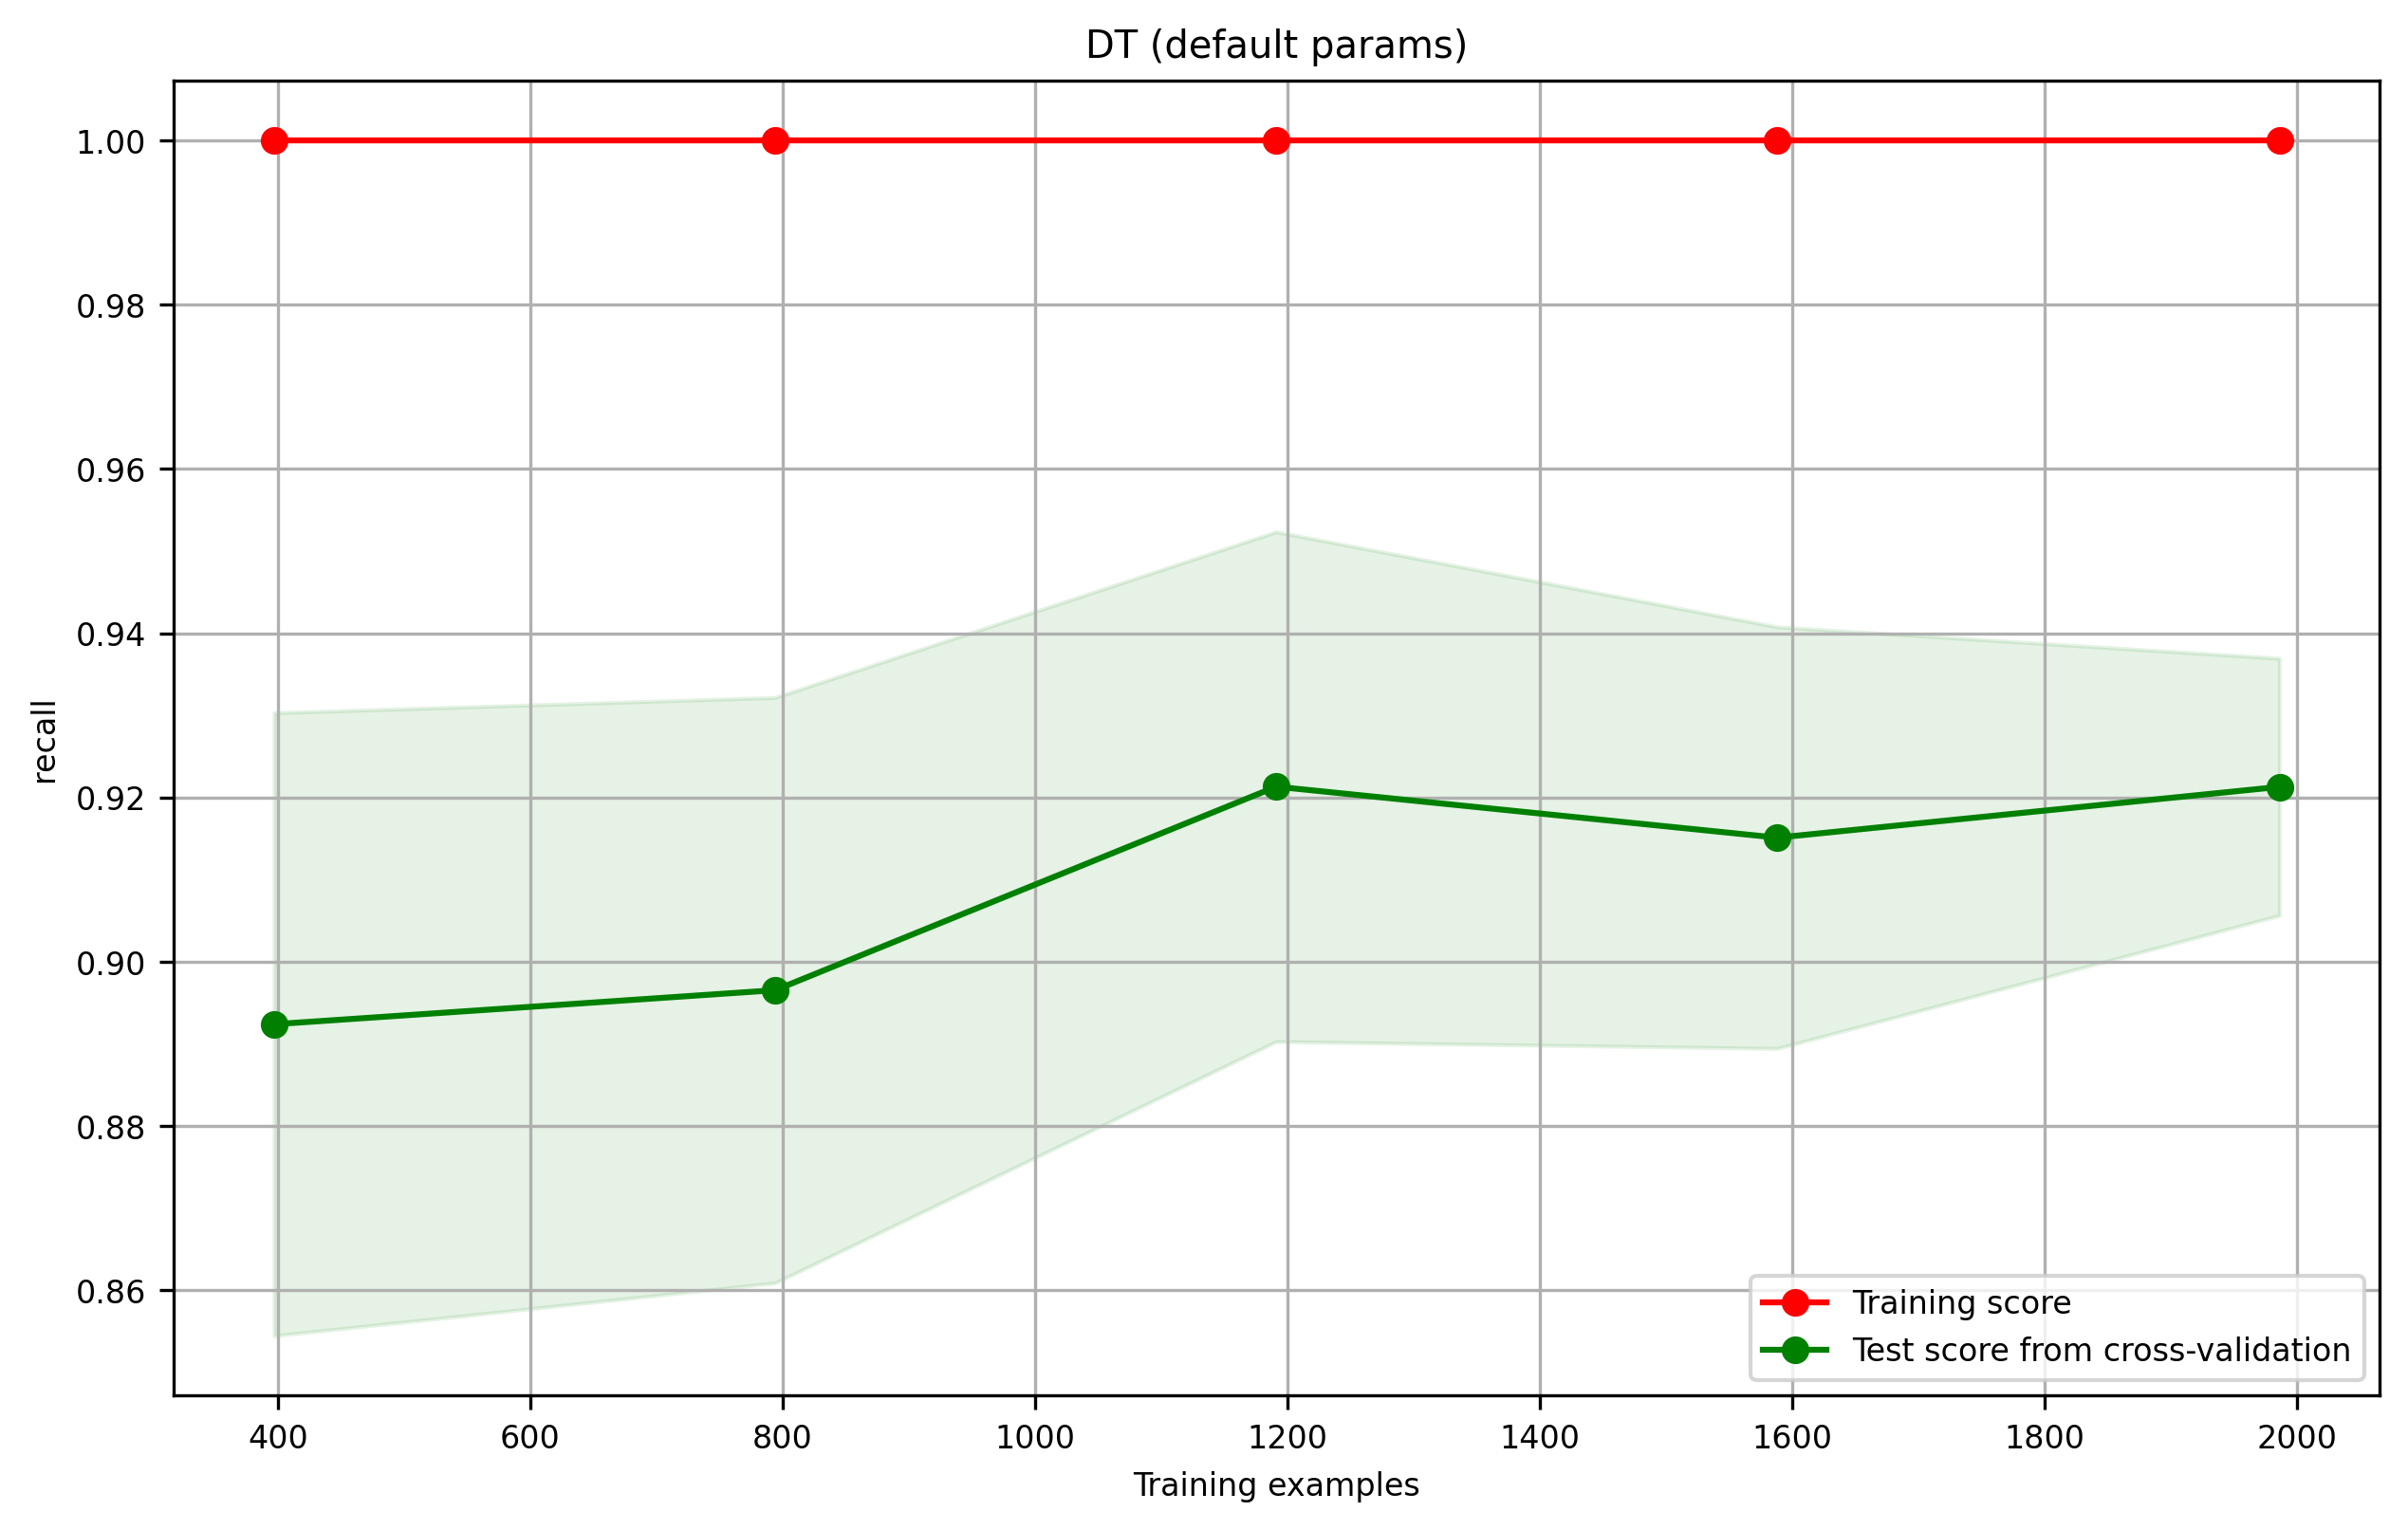

In [44]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

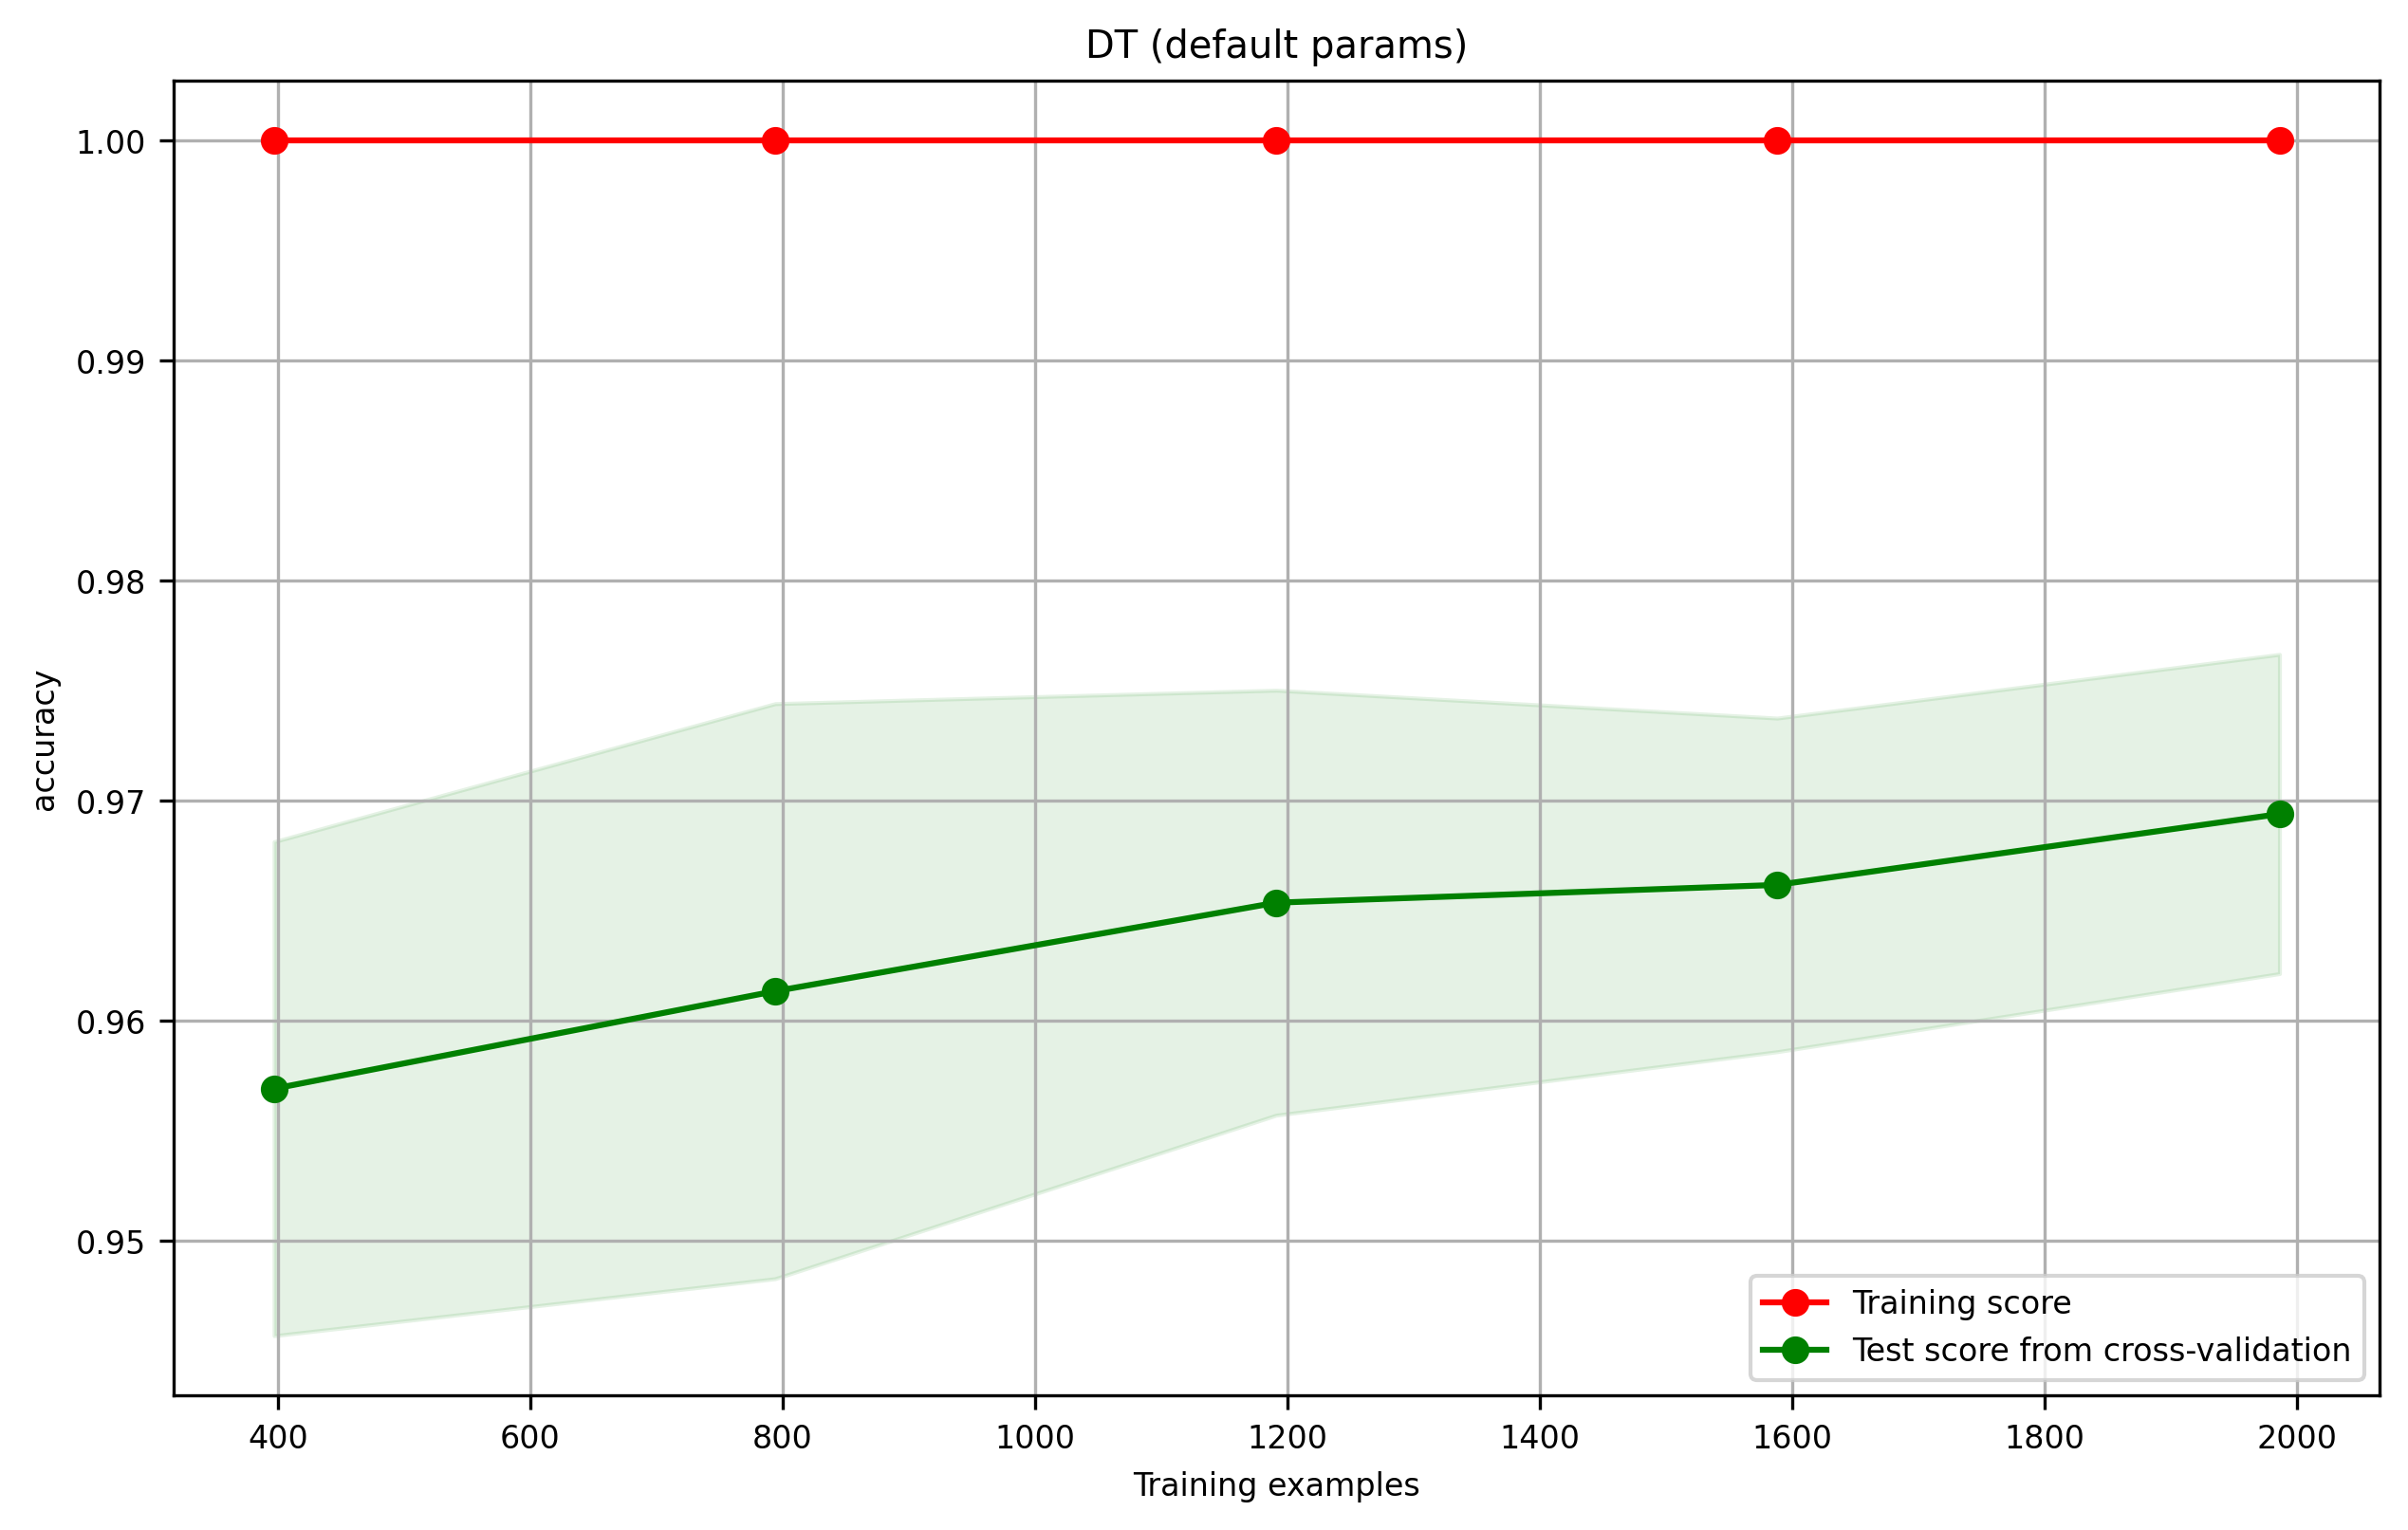

In [45]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?
2. ¿El rendimiento de validación mejora al agregar más ejemplos?
3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.
4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.

1. La curva de entrenamiento siempre estará al máximo para cada caso, pues al no incluir hiperparámetros el modelo siempre buscará el 100% de train score. Por otra parte, la verdadera optimización del modelo a través de los n=5 Folds se observa en el test score, pues a medida que entrenamos más datos y corregimos los desajustes con la cross-validation, este tenderá a aumentar. Un mayor aumento del test score implica que el modelo mejora con una mayor cantidad de datos entrenados, pero a menos de que sea ultra perfecto no alcanzará la precisión máxima como el train score.
2. Sí, el rendimiento de validación mejora al agregar más datos. Sin embargo, esto depende también de los datos que se estén agregando. Veáse el primer gráfico, donde notamos que entre los 1200 y 1600 datos de entrenamiento hay una disminución del recall, lo que puede significar que los datos que se incluyeron al conjunto son outliers que terminaron confudiendo más al modelo. Pero de manera general, una mayor cantidad de datos mejora el rendimiento de la validación.
3. En este caso no hay presencia de un alto sesgo, pues de ser el caso el modelo sería demasiado simple y tanto el train score como el test score sería demasiado bajos. Sin embargo, aunque no sea demasiado grande, hay una brecha entre el train score (que es perfecto) y el test score, lo que puede sugerir la presencia de una alta varianza. En realidad, el train score perfecto nos revela directamente la presencia de un posible sobreajuste, pues para darse esto el entrenamiento debe de realizarse hasta que ya no hayan posibles desviaciones (las cuales son normales en conjuntos de datos). El test score es más bajo, pero observese que este aumenta con una mayor cantidad de datos, lo que es un comportamiento común en alta varianza, pues el modelo se beneficia de tener más datos para mejorar sus predicciones.
4. En general, el entrenamiento del árbol es demasiado complejo, pues al no tener hiperparámetros se produce overfitting. Por otra parte, el modelo se ajusta demasiado al conjunto de entrenamiento, lo que nos reduce la precisión con los datos de prueba. Esto se observa en que el test score es más bajo que el train score, y se beneficia de aumentar la cantidad de datos

### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



In [54]:
model_simple = DecisionTreeClassifier(max_depth=3, random_state=42)

scores_accuracy = cross_validate(model_simple, X, y, cv=cv3, scoring='accuracy')
scores_precision = cross_validate(model_simple, X, y, cv=cv3, scoring='precision')
scores_recall = cross_validate(model_simple, X, y, cv=cv3, scoring='recall')
scores_f1 = cross_validate(model_simple, X, y, cv=cv3, scoring='f1')

print("Árbol restringido (max_depth=3), validación cruzada estratificada:")
print("Accuracy :", "{:.3f}".format(scores_accuracy['test_score'].mean()),
      "±", "{:.3f}".format(scores_accuracy['test_score'].std()))
print("Precision:", "{:.3f}".format(scores_precision['test_score'].mean()),
      "±", "{:.3f}".format(scores_precision['test_score'].std()))
print("Recall   :", "{:.3f}".format(scores_recall['test_score'].mean()),
      "±", "{:.3f}".format(scores_recall['test_score'].std()))
print("F1-score :", "{:.3f}".format(scores_f1['test_score'].mean()),
      "±", "{:.3f}".format(scores_f1['test_score'].std()))


Árbol restringido (max_depth=3), validación cruzada estratificada:
Accuracy : 0.977 ± 0.008
Precision: 0.925 ± 0.023
Recall   : 0.961 ± 0.024
F1-score : 0.942 ± 0.019


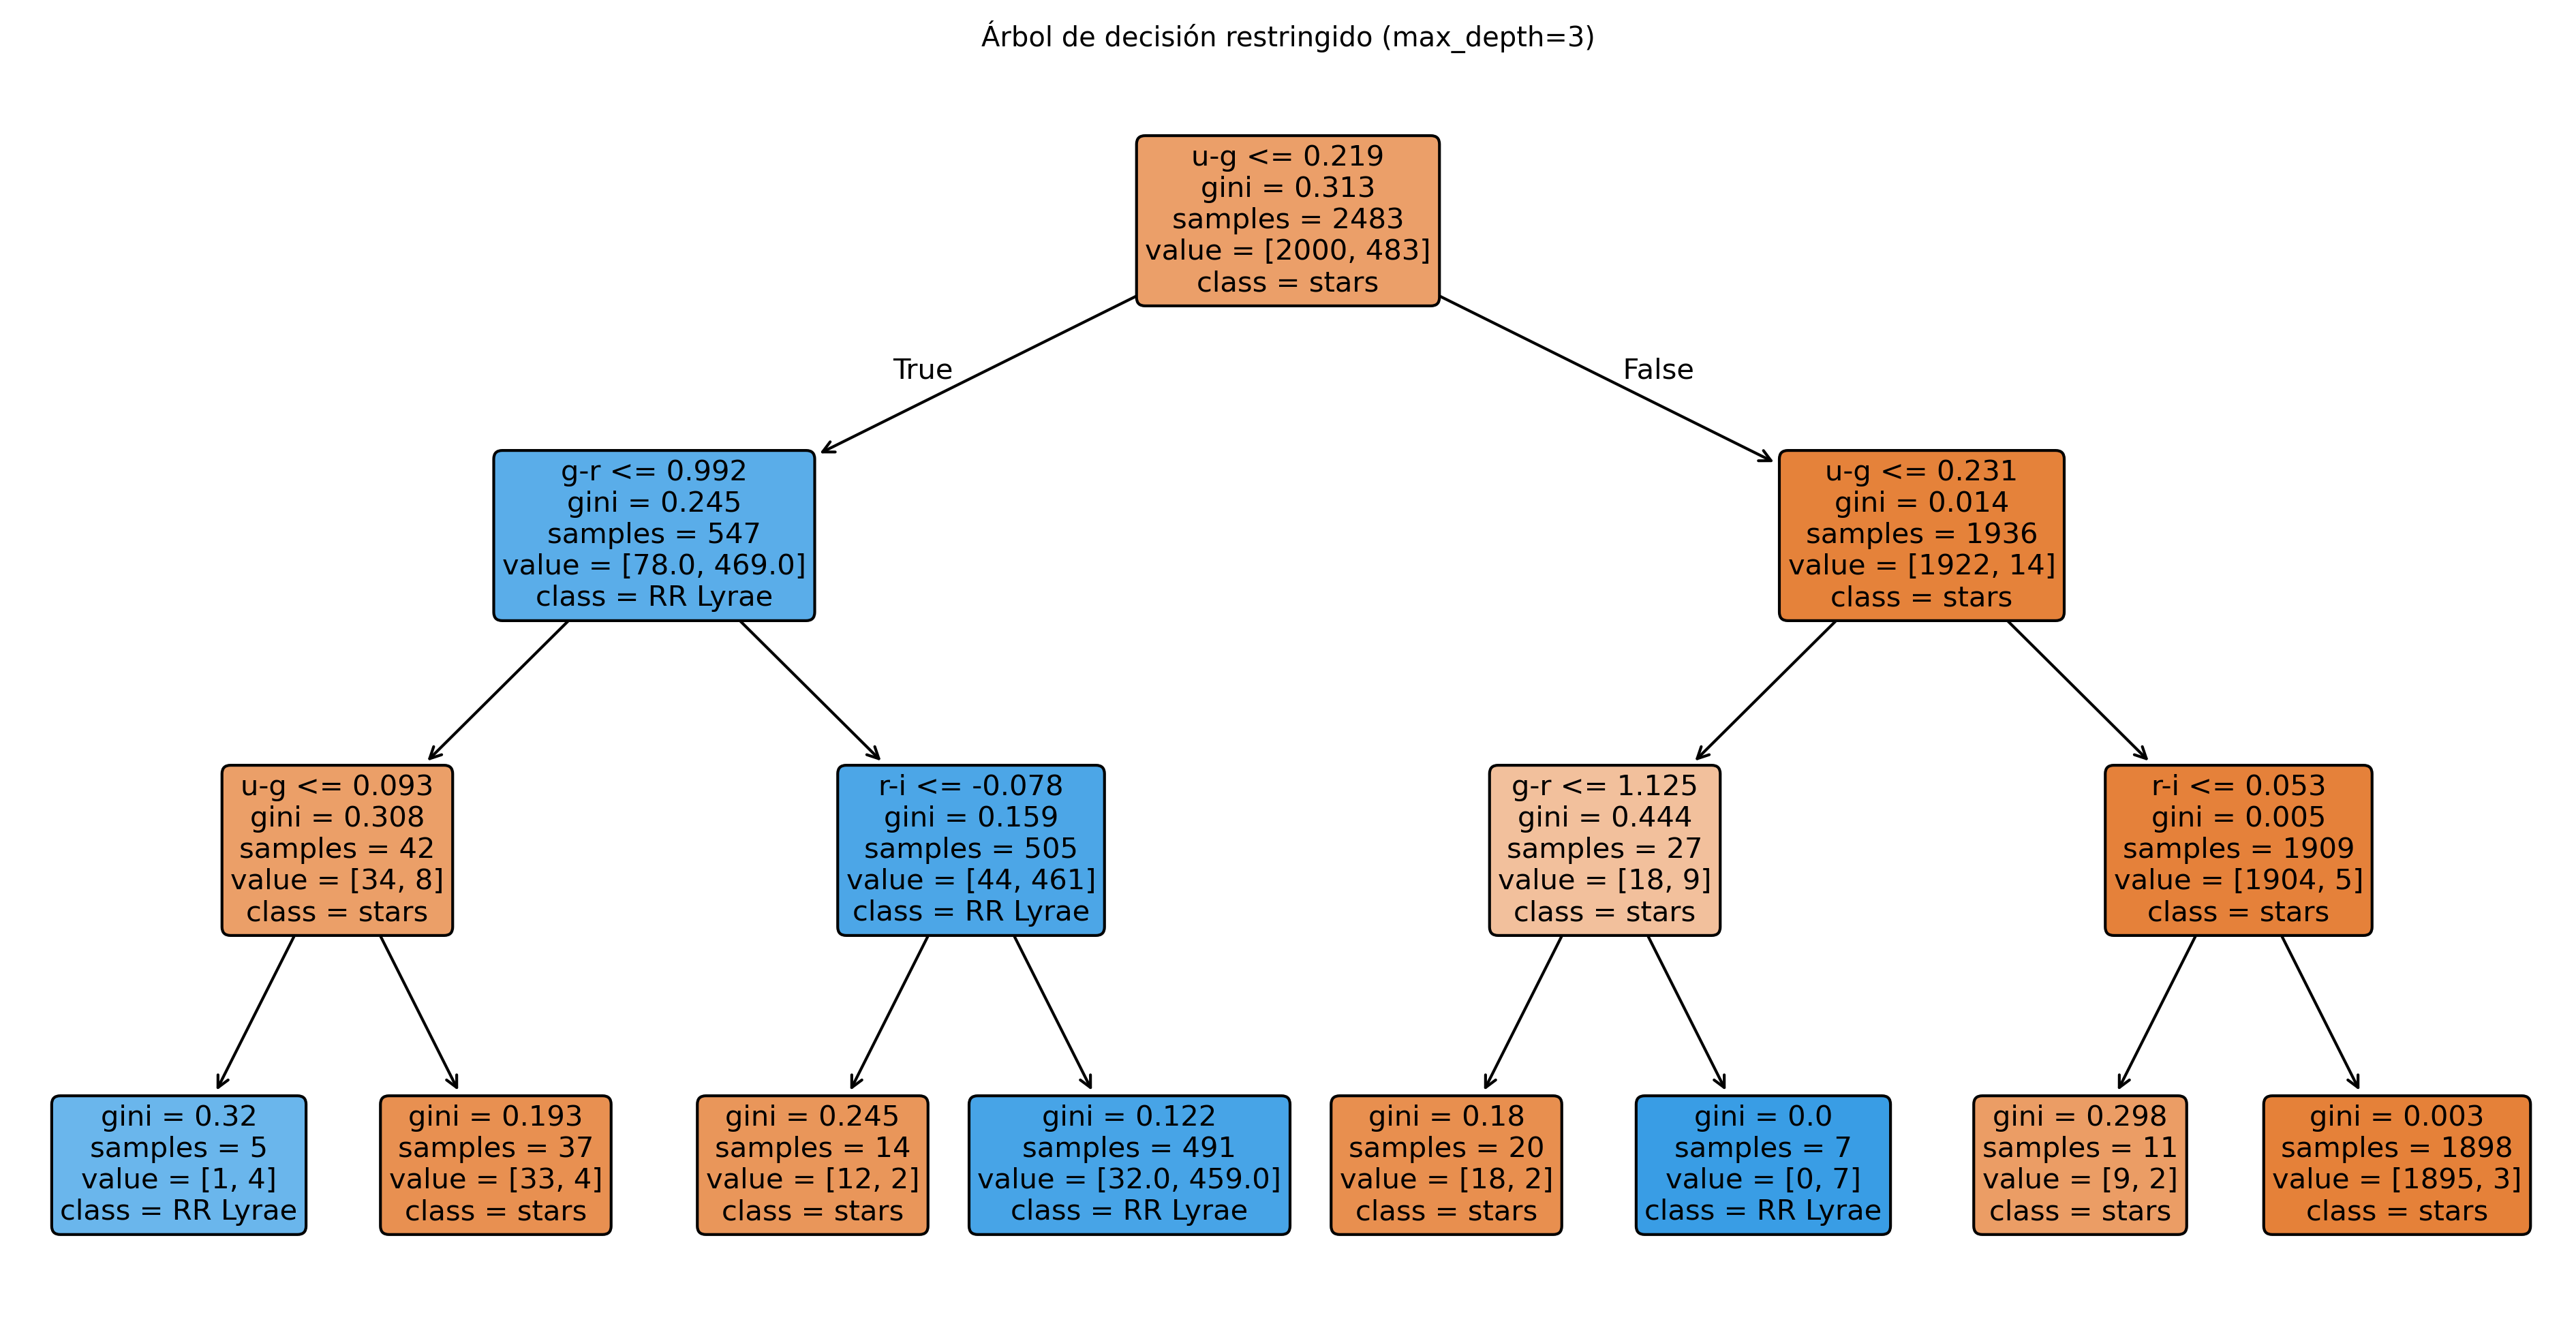

In [56]:
model_simple.fit(X, y) 
plt.figure(figsize=(16,8))

plot_tree(
    model_simple,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de decisión restringido (max_depth=3)")
plt.show()



In [53]:
# Comparación con el árbol base (sin restricciones), usando el mismo esquema
# de validación cruzada (cv3) y la misma métrica (recall) calculada antes en
# 'scores3' (celda de arriba de la sección de cross_validate con recall):
print("Árbol base   - recall (cv3):", "{:.3f}".format(scores3['test_score'].mean()),
      "±", "{:.3f}".format(scores3['test_score'].std()))
print("Árbol simple - recall (cv3):", "{:.3f}".format(scores_recall['test_score'].mean()),
      "±", "{:.3f}".format(scores_recall['test_score'].std()))

# Si quiere comparar también accuracy del árbol base, puede volver a calcularlo:
scores_base_accuracy = cross_validate(DecisionTreeClassifier(random_state=42), X, y,
                                       cv=cv3, scoring='accuracy')
print("Árbol base   - accuracy (cv3):", "{:.3f}".format(scores_base_accuracy['test_score'].mean()))
print("Árbol simple - accuracy (cv3):", "{:.3f}".format(scores_accuracy['test_score'].mean()))

Árbol base   - recall (cv3): 0.927 ± 0.022
Árbol simple - recall (cv3): 0.961 ± 0.024
Árbol base   - accuracy (cv3): 0.971
Árbol simple - accuracy (cv3): 0.977


### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?
2. ¿El árbol más simple empeoró o mejoró la generalización?
3. ¿Qué sugieren estos resultados sobre el árbol base?
4. En este problema, ¿parece conveniente usar el árbol sin restricciones?
5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

1. Mejoró en las dos métricas comparadas:
Accuracy: 0.971 (base) → 0.977 (simple)
Recall: 0.927 (base) → 0.961 (simple)
2. Mejoró. Con solo 3 niveles de profundidad (la raíz divide por u-g <= 0.219, y solo hace 2 cortes más), el árbol generaliza mejor que la versión sin restricciones — la validación cruzada lo confirma con mejores números en ambas métricas
3. Que estaba sobreajustando. El árbol base, al no tener límite de profundidad, se ajustaba a detalles específicos (ruido) del set de entrenamiento que no representan patrones reales generalizables
4. No. El árbol restringido no solo es más simple e interpretable, sino que además generaliza mejor. No hay ninguna ventaja real en usar la versión sin restricciones para este dataset
5. El recall, dado el objetivo científico de encontrar la mayor cantidad posible de RR Lyrae (clase minoritaria: solo 483 de 2483 en el nodo raíz, un dataset desbalanceado). El árbol simple mejora notoriamente el recall (0.927 → 0.961) sin perder accuracy, lo que lo hace la mejor opción también según esta métrica

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?
2. ¿Qué ocurre cuando `k` es muy pequeño?
3. ¿Qué ocurre cuando `k` es muy grande?
4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?
5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

In [59]:
from sklearn import neighbors 
import sklearn
kNN_model = neighbors.KNeighborsClassifier(n_neighbors = 3)
# Prueba con k = 1, 3, 5, 8, 15
kNN_model

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [60]:
scaler = sklearn.preprocessing.StandardScaler()
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [63]:
scaledXTrain = scaler.transform(X_train)
scaledXtest = scaler.transform(X_test) 
kNN_model.fit(scaledXTrain, y_train)
scaledytestpred = kNN_model.predict(scaledXtest)


In [64]:
print("Train Score:", metrics.accuracy_score(y_train, kNN_model.predict(scaledXTrain))) 
print("Test Score:", metrics.accuracy_score(y_test, kNN_model.predict(scaledXtest))) 
print("Precision:", metrics.precision_score(y_test, kNN_model.predict(scaledXtest)))
print("Recall   :", metrics.recall_score(y_test, kNN_model.predict(scaledXtest)))
print("F1-score :", metrics.f1_score(y_test, kNN_model.predict(scaledXtest)))

Train Score: 0.9873417721518988
Test Score: 0.9691275167785235
Precision: 0.8955223880597015
Recall   : 0.9302325581395349
F1-score : 0.9125475285171103


In [66]:
kNN_scores1 = cross_validate(kNN_model, X,y, cv = cv1, scoring = 'recall', return_train_score = True)
kNN_scores2 = cross_validate(kNN_model, X,y, cv = cv2, scoring = 'recall', return_train_score = True)
kNN_scores3 = cross_validate(kNN_model, X,y, cv = cv3, scoring = 'recall', return_train_score = True)

/home/huawei/miniconda3/envs/ciencia/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/huawei/miniconda3/envs/ciencia/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/huawei/miniconda3/envs/ciencia/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/h

In [67]:
print("{:.3f}".format(kNN_scores1['test_score'].mean()), "{:.3f}".format(kNN_scores1['test_score'].std()))
print("{:.3f}".format(kNN_scores2['test_score'].mean()), "{:.3f}".format(kNN_scores2['test_score'].std()))
print("{:.3f}".format(kNN_scores3['test_score'].mean()), "{:.3f}".format(kNN_scores3['test_score'].std()))


nan nan
0.969 0.003
0.973 0.011


In [68]:
print("{:.3f}".format(kNN_scores1['test_score'].mean()), "{:.3f}".format(kNN_scores1['train_score'].mean()))
print("{:.3f}".format(kNN_scores2['test_score'].mean()), "{:.3f}".format(kNN_scores2['train_score'].mean()))
print("{:.3f}".format(kNN_scores3['test_score'].mean()), "{:.3f}".format(kNN_scores3['train_score'].mean()))

nan nan
0.969 0.980
0.973 0.979


In [69]:
kNNy_cv3 = cross_val_predict(kNN_model, X, y, cv = cv3)

In [70]:
metrics.confusion_matrix(targets, kNNy_cv3)

array([[1960,   40],
       [  13,  470]])

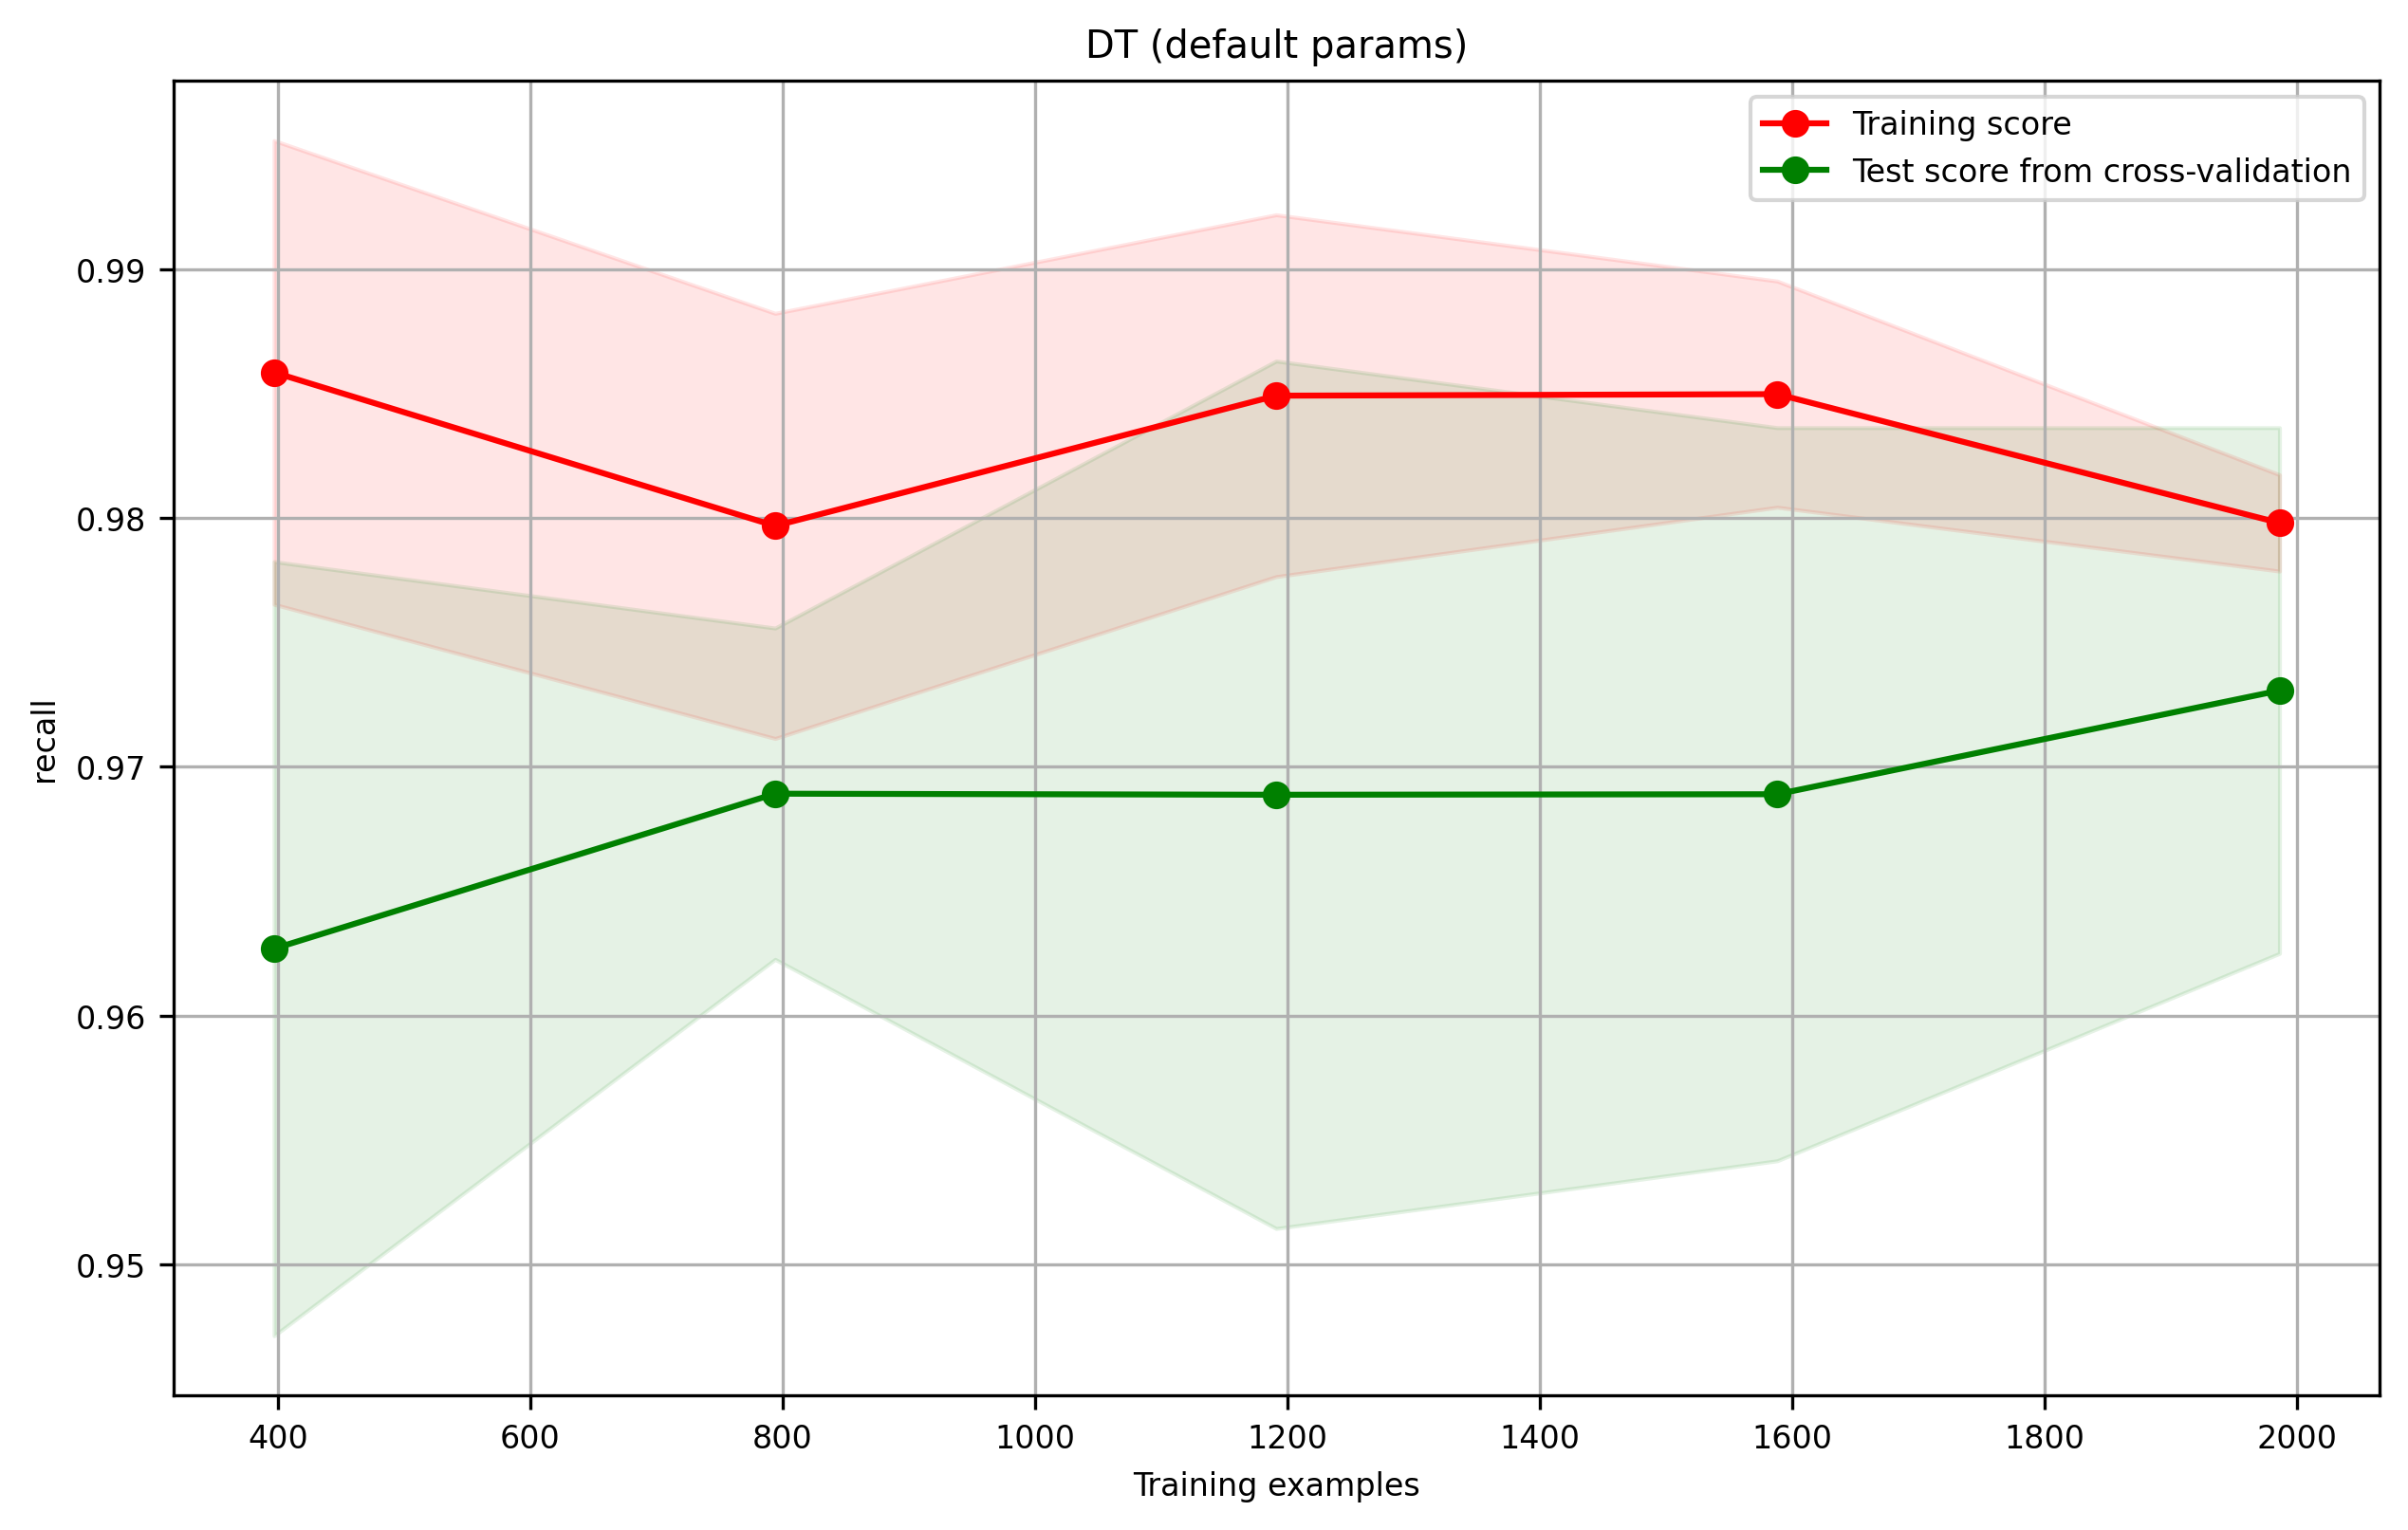

In [71]:
plot_learning_curve(kNN_model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

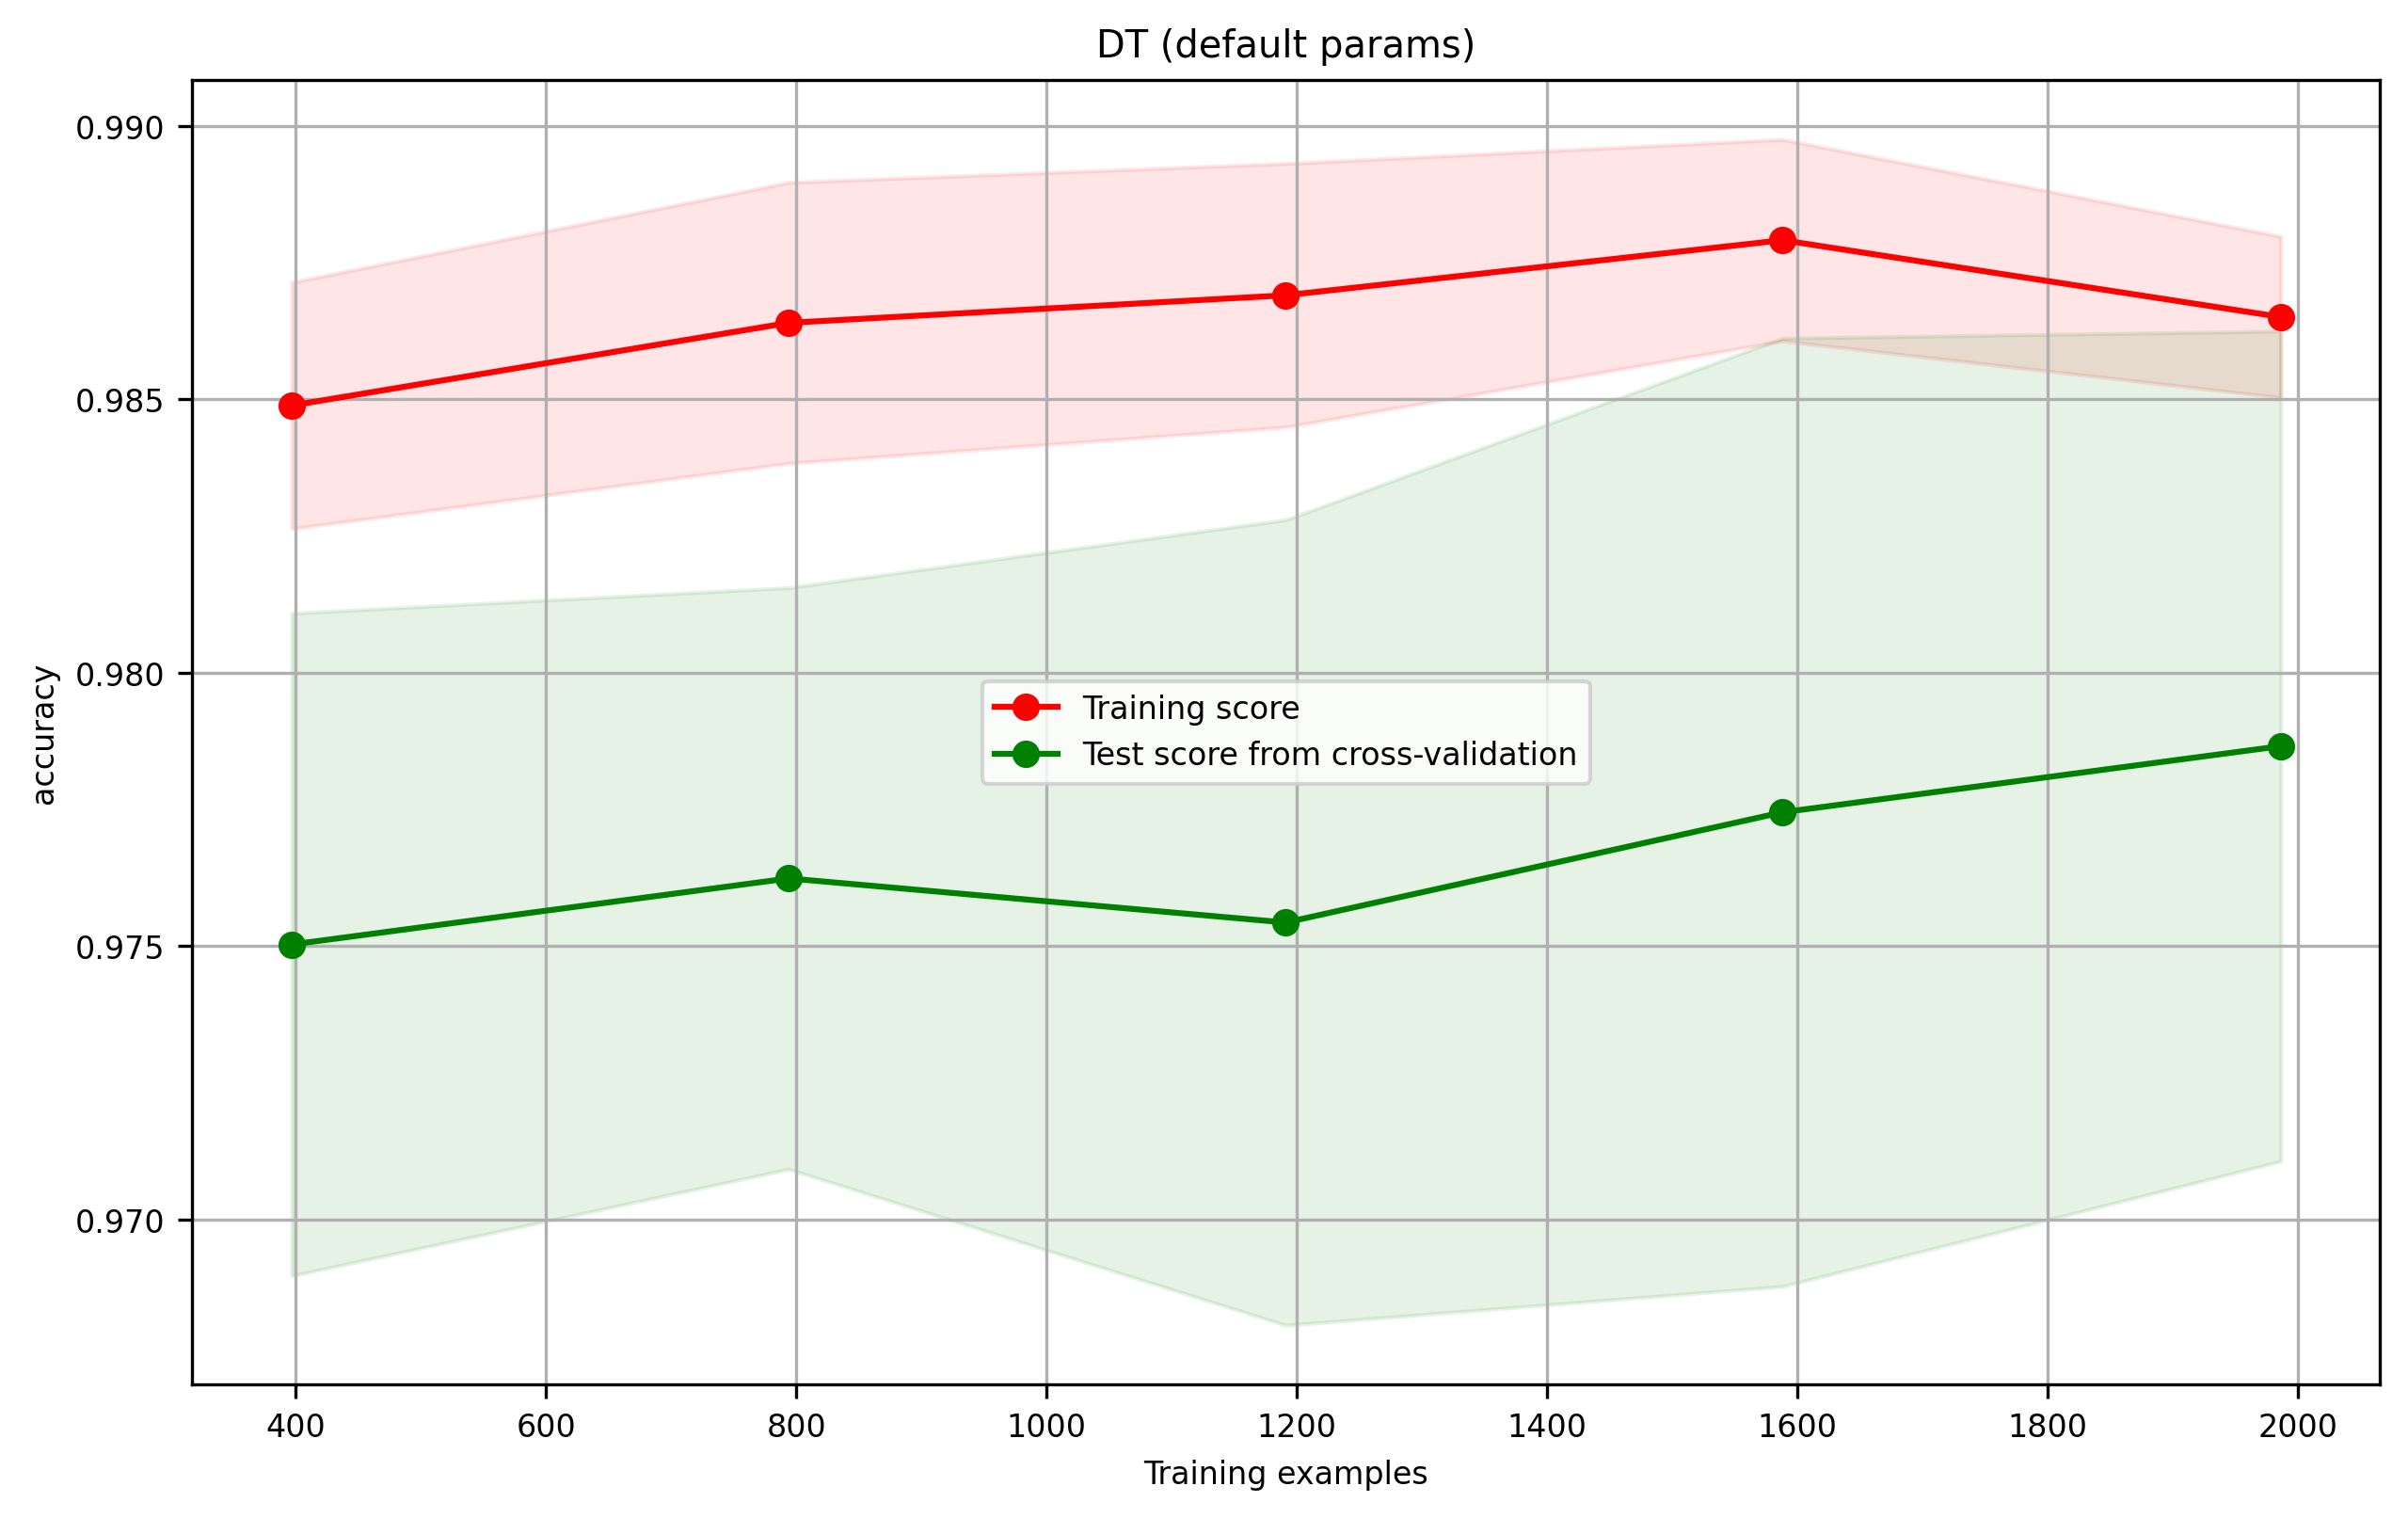

In [72]:
plot_learning_curve(kNN_model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

In [73]:
from sklearn.pipeline import make_pipeline

kNN_pipeline = make_pipeline(sklearn.preprocessing.StandardScaler(), neighbors.KNeighborsClassifier(n_neighbors=15))

scoring = ['accuracy', 'precision', 'recall', 'f1']

kNN_scores3 = cross_validate(kNN_pipeline, X, y, cv=cv3, scoring=scoring, return_train_score=True)

for m in scoring:
    print(f"{m}: test={kNN_scores3['test_' + m].mean():.3f} (+/- {kNN_scores3['test_' + m].std():.3f})  "
          f"train={kNN_scores3['train_' + m].mean():.3f}")

accuracy: test=0.974 (+/- 0.008)  train=0.976
precision: test=0.900 (+/- 0.032)  train=0.910
recall: test=0.975 (+/- 0.016)  train=0.975
f1: test=0.936 (+/- 0.019)  train=0.942


Preguntas¶

    ¿Cómo se compara el rendimiento de kNN con el del árbol simple?
    ¿Qué ocurre cuando k es muy pequeño?
    ¿Qué ocurre cuando k es muy grande?
    ¿Qué valor de k parece dar el mejor equilibrio entre precision y recall?
    ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?


1. Entre el kNN sin cross validation y el DT simple los resultados de las métricas son bastantes similares, por lo que ambos modelos funcionan bastante bien con este conjunto de datos. Sin embargo, aplicar el cross validation mejora notablemente los resultados, y eso lo observamos en los valores obtenidos en las métricas del modelo kNN entrenado con la validación cruzada. De la misma manera, esta mejora en los resultados es esperable también si aplicamos cross validation al DT simple
2. Cuando k es muy pequeño, el conjunto de datos de entrenamiento solo toma a los pocos k vecinos más cercanos que tiene, lo que puede resultar en un subfitting, pues el modelo podría no conseguir información suficiente para dar con un resultado óptimo. En los resultados se observa que k=1 y k=3 tienen resultados generales en las métricas más bajos a los de k=5
3. Cuando k es muy grande, el conjunto de datos de entrenamiento toma a la gran cantidad de k vecinos cercanos, lo que puede resultar en un overfitting, pues el modelo podría estar modelando grandes áreas de manera incorrecta con preferencia hacia una de las clases.
4. Entre los valores de k probados (k=1,3,5,8,15) el que da el mejor F1-score (equilibrio entre recall y precision) es el k=5. Esto nos dice que debemos de encontrar un valor del hiperparametro k justo, que no sea demasiado grande ni demasiado chico para nuestro conjunto de datos
5. La ventaja de utilizar fronteras no rectangulares es que se define el espacio según un área alrededor de un punto, lo que permite representar situaciones en las que las clases se encuentran mezcladas o donde existen grupos minoritarios dentro de otra clase. Por ejemplo, una frontera rectangular podría tener problemas para separar correctamente un conjunto de datos de una clase que se encuentra rodeada por datos de otra clase. En cambio, kNN puede generar fronteras más felxibles e irregulares, y así clasificar estos puntos considerando la distribución local de sus vecinos

## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.